In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Задание 1. 

Поработайте с датасетом про цены мобильных телефонов, обучите регрессию. 

In [254]:
data = pd.read_csv('Cellphone.csv')
data.head()

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


<Axes: >

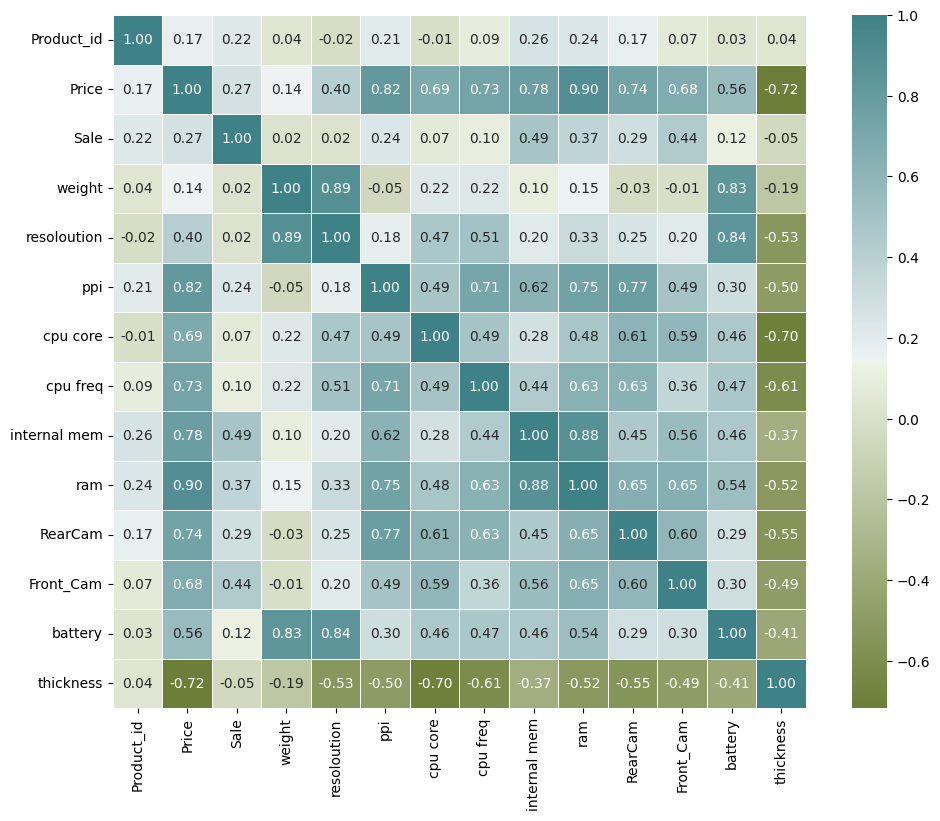

In [245]:
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt
plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)

In [246]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [255]:
data.drop(['Product_id', 'weight', 'Sale', 'resoloution'], axis=1, inplace=True) #убираем признаки, которые < 0.50

In [256]:
X = data.copy().drop('Price', axis=1) 
y = data['Price']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=111)

scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

regressor = LinearRegression()
regressor.fit(Xtrain, ytrain)

ypred_train = regressor.predict(Xtrain)
ypred_test = regressor.predict(Xtest)

In [257]:
r2_score(ytrain,ypred_train), r2_score(ytest,ypred_test)

(0.9452349235886908, 0.9419433685155438)

In [258]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(regressor.coef_))], axis = 1)
coefficients

,0,0
0,ppi,195.320876
1,cpu core,126.209897
2,cpu freq,41.727193
3,internal mem,170.897149
4,ram,135.055379
5,RearCam,8.274693
6,Front_Cam,25.506990
7,battery,49.823588
8,thickness,-139.993942


In [259]:
#L1-регуляризация
regressor2 = Lasso(alpha=10)
regressor2.fit(Xtrain, ytrain)

ypred2 = regressor2.predict(Xtest)

print('Scores:', r2_score(ytest,ypred2), mean_squared_error(ytest,ypred2))
print(regressor2.coef_,'\n')

Scores: 0.9412819207685683 47985.63475656259
[ 190.59636332  126.35079622   39.86378954  160.95971507  150.38893217
    3.87422422   20.14974604   41.91134828 -136.87955873] 



In [260]:
#разные значения параметра регуляризации а
for a in np.arange(0.1,100.1,25):
    regressor2 = Lasso(alpha=a)
    regressor2.fit(Xtrain, ytrain)

    ypred2 = regressor2.predict(Xtest)

    print('alpha={}'.format(a))
    print('Scores:', r2_score(ytest,ypred2), mean_squared_error(ytest,ypred2))
    print(regressor2.coef_,'\n')

alpha=0.1
Scores: 0.9419487505657663 47440.68758676477
[ 195.21577272  126.28508445   41.7724077   170.89353975  135.18147285
    8.22463545   25.41988993   49.69476    -139.92111818] 

alpha=25.1
Scores: 0.9390683770271582 49794.58870879142
[ 182.51617311  125.72257201   36.52157289  146.6750053   172.60376359
    0.           11.55626016   30.37796805 -132.33843796] 

alpha=50.1
Scores: 0.9324129068486349 55233.5772673419
[ 167.02009531  121.35188843   30.48791571  124.41524602  205.19671019
    0.            0.           12.98353226 -124.68484414] 

alpha=75.1
Scores: 0.9216252433821377 64049.48006517982
[ 154.26144241  111.21962101   24.58952455   99.31130522  231.51612752
    0.            0.            0.         -116.57364217] 



In [261]:
#оптимальное значение параметра регуляризации по кросс-валидации
from sklearn.linear_model import LassoCV

n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas, 
                   cv=3, random_state=17)
lasso_cv.fit(X, y)

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=3, random_state=17)

In [262]:
lasso_cv.alpha_

np.float64(10.0)

In [263]:
#обучение с найденным параметром регуляризации альфа
regressor2 = Lasso(alpha=lasso_cv.alpha_)

regressor2.fit(Xtrain, ytrain)

ypred2_train = regressor2.predict(Xtrain)
ypred2_test = regressor2.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred2_train), r2_score(ytest,ypred2_test))

Scores: 0.9448154683368949 0.9412819207685683


In [264]:
#L2-регуляризация
from sklearn.linear_model import Ridge

for a in np.arange(0.1,10.1,2.5):
    regressor3 = Ridge(alpha=a)
    regressor3.fit(Xtrain, ytrain)

    ypred3 = regressor3.predict(Xtest)

    print('alpha={}'.format(a))
    print('Scores:',r2_score(ytest,ypred3), mean_squared_error(ytest,ypred3))
    print(regressor3.coef_)

alpha=0.1
Scores: 0.9419682454565491 47424.75595683124
[ 194.96776178  126.05773022   41.90217718  170.76337699  135.11654853
    8.52695915   25.62721125   49.85721893 -139.86439922]
alpha=2.6
Scores: 0.9424136166418977 47060.789367478064
[ 187.03293108  122.46379781   45.87037268  167.60256698  136.16794659
   14.31626225   28.5524792    50.76629039 -136.83049814]
alpha=5.1
Scores: 0.9425952921818606 46912.32034023863
[ 180.46419241  119.2581734    49.1952611   164.72126861  136.59022131
   19.25564242   31.28542834   51.72289892 -134.12284352]
alpha=7.6
Scores: 0.9425887622318656 46917.65675109427
[ 174.89628507  116.40228715   52.02585417  162.05740316  136.64046904
   23.51800625   33.80480104   52.65736914 -131.67216919]


In [265]:
#оптимальное a по кросс-валидации
from sklearn.linear_model import RidgeCV

n_alphas = 200
ridge_alphas = np.logspace(0, 6, n_alphas)

ridge_cv = RidgeCV(alphas=ridge_alphas, 
                   scoring='neg_mean_squared_error',
                   cv=3)
ridge_cv.fit(X, y)

RidgeCV(alphas=array([1.00000000e+00, 1.07189132e+00, 1.14895100e+00, 1.23155060e+00,
       1.32008840e+00, 1.41499130e+00, 1.51671689e+00, 1.62575567e+00,
       1.74263339e+00, 1.86791360e+00, 2.00220037e+00, 2.14614120e+00,
       2.30043012e+00, 2.46581108e+00, 2.64308149e+00, 2.83309610e+00,
       3.03677112e+00, 3.25508860e+00, 3.48910121e+00, 3.73993730e+00,
       4.00880633e+00, 4.29700470e+0...
       2.02550194e+05, 2.17111795e+05, 2.32720248e+05, 2.49450814e+05,
       2.67384162e+05, 2.86606762e+05, 3.07211300e+05, 3.29297126e+05,
       3.52970730e+05, 3.78346262e+05, 4.05546074e+05, 4.34701316e+05,
       4.65952567e+05, 4.99450512e+05, 5.35356668e+05, 5.73844165e+05,
       6.15098579e+05, 6.59318827e+05, 7.06718127e+05, 7.57525026e+05,
       8.11984499e+05, 8.70359136e+05, 9.32930403e+05, 1.00000000e+06]),
        cv=3, scoring='neg_mean_squared_error')

In [266]:
ridge_cv.alpha_

np.float64(13.049019780144022)

In [267]:
regressor3 = Lasso(alpha=ridge_cv.alpha_)

regressor3.fit(Xtrain, ytrain)

ypred3_train = regressor3.predict(Xtrain)
ypred3_test = regressor3.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred3_train), r2_score(ytest,ypred3_test))

Scores: 0.9445203778860997 0.9409477657819624


# Задание 2. 

Поработайте с датасетом diet_data (Его создатель решил похудеть, подсчитывая калории, и ему это действительно удалось; в течение времени, пока худел, он записывал, что и какое он ест). Целевая колонка - change. 

In [371]:
data = pd.read_csv('diet_data.csv')
data.head()

,Date,Stone,Pounds,Ounces,weight_oz,calories,cals_per_oz,five_donuts,walk,run,wine,prot,weight,change
0,7/30/2018,12.0,2.0,6.0,2726.0,1950.0,0.72,1.0,1.0,0.0,0.0,0.0,0.0,-30.0
1,7/31/2018,12.0,0.0,8.0,2696.0,2600.0,0.96,1.0,0.0,0.0,0.0,0.0,0.0,8.0
2,8/1/2018,12.0,1.0,0.0,2704.0,2500.0,0.92,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,8/2/2018,12.0,1.0,0.0,2704.0,1850.0,0.68,1.0,1.0,0.0,1.0,0.0,0.0,-40.0
4,8/3/2018,11.0,12.0,8.0,2664.0,2900.0,1.09,1.0,1.0,0.0,0.0,0.0,0.0,14.0


In [372]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         150 non-null    object 
 1   Stone        142 non-null    float64
 2   Pounds       142 non-null    float64
 3   Ounces       142 non-null    float64
 4   weight_oz    149 non-null    float64
 5   calories     140 non-null    float64
 6   cals_per_oz  147 non-null    object 
 7   five_donuts  140 non-null    float64
 8   walk         140 non-null    float64
 9   run          140 non-null    float64
 10  wine         140 non-null    float64
 11  prot         140 non-null    float64
 12  weight       140 non-null    float64
 13  change       147 non-null    float64
dtypes: float64(12), object(2)
memory usage: 16.6+ KB


In [373]:
data.dropna(inplace=True)

import re
data.Date = data.Date.apply(lambda x: re.sub(r'/', '', str(x)))

<Axes: >

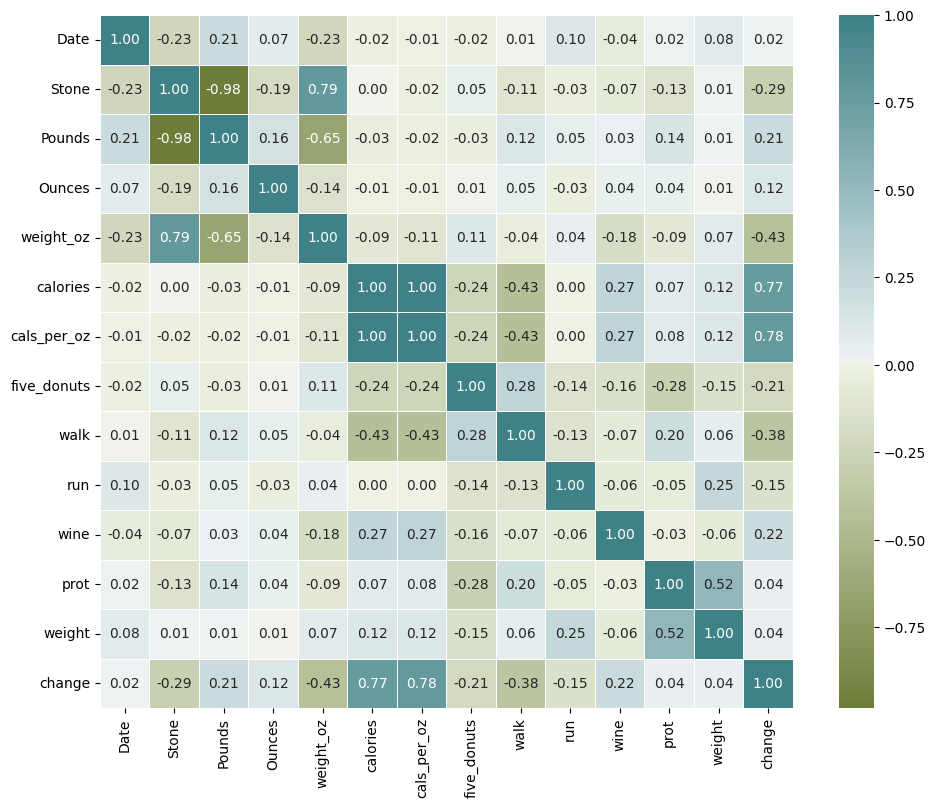

In [374]:
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt
plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)

In [375]:
data.drop(['Date', 'prot', 'weight', 'Ounces', 'Pounds', 'wine'], axis=1, inplace=True)

In [376]:
X = data.copy().drop('change', axis=1)
y = data['change']
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=111)

scaler = StandardScaler().fit(Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

regressor = LinearRegression()
regressor.fit(Xtrain, ytrain)

ypred_train = regressor.predict(Xtrain)
ypred_test = regressor.predict(Xtest)

In [377]:
r2_score(ytrain,ypred_train), r2_score(ytest,ypred_test)

(0.8003150478256148, 0.48179203414601435)

In [378]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(regressor.coef_))], axis = 1)
coefficients

,0,0
0,Stone,-1.122700
1,weight_oz,-6.246324
2,calories,-79.490946
3,cals_per_oz,97.108237
4,five_donuts,0.100189
5,walk,-4.034928
6,run,-4.436565


In [379]:
#L1-регуляризация
regressor2 = Lasso(alpha=10)
regressor2.fit(Xtrain, ytrain)

ypred2 = regressor2.predict(Xtest)

print('Scores:', r2_score(ytest,ypred2), mean_squared_error(ytest,ypred2))
print(regressor2.coef_,'\n')

Scores: 0.2287948154547239 406.3897197723967
[-0.         -0.          0.         10.15387281 -0.         -0.
 -0.        ] 



In [380]:
#разные значения параметра регуляризации а
for a in np.arange(0.1,100.1,25):
    regressor2 = Lasso(alpha=a)
    regressor2.fit(Xtrain, ytrain)

    ypred2 = regressor2.predict(Xtest)

    print('alpha={}'.format(a))
    print('Scores:', r2_score(ytest,ypred2), mean_squared_error(ytest,ypred2))
    print(regressor2.coef_,'\n')

alpha=0.1
Scores: 0.5064777307931723 260.06357413514695
[-1.17772002 -7.80634017  5.38662509 12.08500713 -0.         -3.76010452
 -4.29402257] 

alpha=25.1
Scores: -0.1771110686172941 620.2834821428571
[-0. -0.  0.  0. -0. -0. -0.] 

alpha=50.1
Scores: -0.1771110686172941 620.2834821428571
[-0. -0.  0.  0. -0. -0. -0.] 

alpha=75.1
Scores: -0.1771110686172941 620.2834821428571
[-0. -0.  0.  0. -0. -0. -0.] 



/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.107e+00, tolerance: 7.072e+00
  model = cd_fast.enet_coordinate_descent(


In [381]:
#оптимальное значение параметра регуляризации по кросс-валидации
from sklearn.linear_model import LassoCV

n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas, 
                   cv=3, random_state=17)
lasso_cv.fit(X, y)

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=3, random_state=17)

In [382]:
lasso_cv.alpha_

np.float64(0.3487437185929648)

In [385]:
#обучение с найденным параметром регуляризации а
regressor2 = Lasso(alpha=lasso_cv.alpha_)

regressor2.fit(Xtrain, ytrain)

ypred2_train = regressor2.predict(Xtrain)
ypred2_test = regressor2.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred2_train), r2_score(ytest,ypred2_test))

Scores: 0.7984118684916965 0.509197375625565


In [386]:
#L2-регуляризация
from sklearn.linear_model import Ridge

for a in np.arange(0.1,10.1,2.5):
    regressor3 = Ridge(alpha=a)
    regressor3.fit(Xtrain, ytrain)

    ypred3 = regressor3.predict(Xtest)

    print('alpha={}'.format(a))
    print('Scores:',r2_score(ytest,ypred3), mean_squared_error(ytest,ypred3))
    print(regressor3.coef_)

alpha=0.1
Scores: 0.504243849268073 261.2407271226818
[-1.28497393 -7.77352119  3.41290416 14.09543313 -0.02423501 -3.86007775
 -4.40133701]
alpha=2.6
Scores: 0.5062423419863056 260.187613227696
[-1.49939181 -7.5516025   8.3927158   8.94627763 -0.08680389 -3.81965672
 -4.32822197]
alpha=5.1
Scores: 0.5066726693086244 259.960850488762
[-1.66259364 -7.282485    8.41932065  8.75754572 -0.13796995 -3.78866271
 -4.25719817]
alpha=7.6
Scores: 0.5068002611256757 259.8936154599839
[-1.79376634 -7.04668093  8.3771595   8.63923971 -0.18536235 -3.75740806
 -4.18694312]


In [387]:
#оптимальное a по кросс-валидации
from sklearn.linear_model import RidgeCV

n_alphas = 200
ridge_alphas = np.logspace(0, 6, n_alphas)

ridge_cv = RidgeCV(alphas=ridge_alphas, 
                   scoring='neg_mean_squared_error',
                   cv=3)
ridge_cv.fit(X, y)

RidgeCV(alphas=array([1.00000000e+00, 1.07189132e+00, 1.14895100e+00, 1.23155060e+00,
       1.32008840e+00, 1.41499130e+00, 1.51671689e+00, 1.62575567e+00,
       1.74263339e+00, 1.86791360e+00, 2.00220037e+00, 2.14614120e+00,
       2.30043012e+00, 2.46581108e+00, 2.64308149e+00, 2.83309610e+00,
       3.03677112e+00, 3.25508860e+00, 3.48910121e+00, 3.73993730e+00,
       4.00880633e+00, 4.29700470e+0...
       2.02550194e+05, 2.17111795e+05, 2.32720248e+05, 2.49450814e+05,
       2.67384162e+05, 2.86606762e+05, 3.07211300e+05, 3.29297126e+05,
       3.52970730e+05, 3.78346262e+05, 4.05546074e+05, 4.34701316e+05,
       4.65952567e+05, 4.99450512e+05, 5.35356668e+05, 5.73844165e+05,
       6.15098579e+05, 6.59318827e+05, 7.06718127e+05, 7.57525026e+05,
       8.11984499e+05, 8.70359136e+05, 9.32930403e+05, 1.00000000e+06]),
        cv=3, scoring='neg_mean_squared_error')

In [388]:
ridge_cv.alpha_

np.float64(4.297004704320841)

In [389]:
regressor3 = Lasso(alpha=ridge_cv.alpha_)

regressor3.fit(Xtrain, ytrain)

ypred3_train = regressor3.predict(Xtrain)
ypred3_test = regressor3.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred3_train), r2_score(ytest,ypred3_test))

Scores: 0.7014592877607475 0.4793395843165773


# Задание 3. 

Поработайте с датасетом Life Expectancy. Целевая колонка - Life Expectancy, собственно. 

In [390]:
data = pd.read_csv('Life Expectancy Data.csv')
data.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [391]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [392]:
print(data.columns)

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')


In [393]:
data.columns = data.columns.str.strip() #убираем лишние пробелы из названий колонок

In [394]:
data.drop(['Country'], axis=1, inplace=True)
data = pd.get_dummies(data, columns=['Status'], dtype=int)
data = data.fillna(data.mean())

<Axes: >

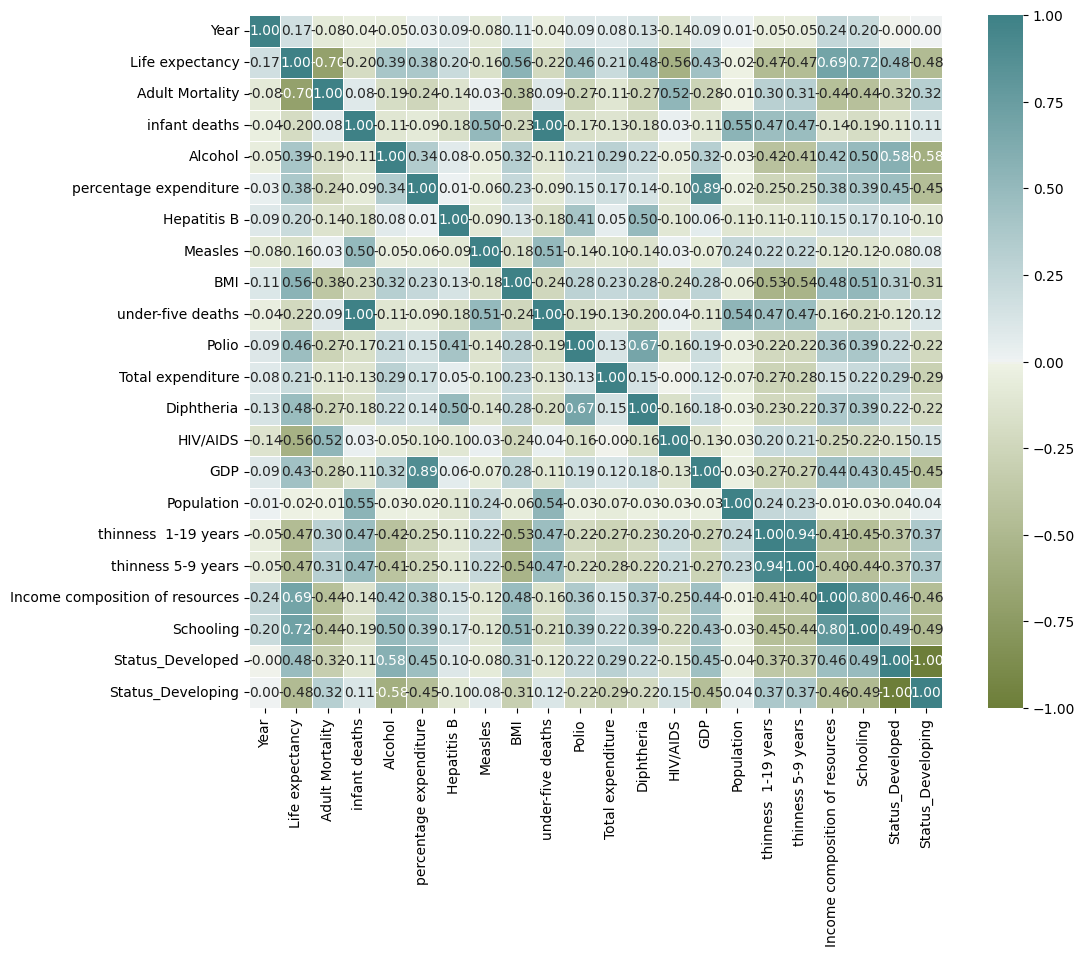

In [395]:
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt

plt.figure(figsize=(12,9))

corr = data.corr()

sns.heatmap(corr,annot=True,linewidths=.5,fmt= '.2f',\
            mask=np.zeros_like(corr, dtype=bool), \
            cmap=sns.diverging_palette(100,200,as_cmap=True), square=True)

In [396]:
data.drop(['Year', 'Hepatitis B', 'Total expenditure', 'percentage expenditure', 'Population', 'infant deaths', 'under-five deaths', 'Measles'], axis=1, inplace=True)

In [397]:
X = data.copy().drop('Life expectancy', axis=1)
y = data['Life expectancy']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=111)

scaler = StandardScaler().fit(Xtrain) 
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

regressor = LinearRegression()
regressor.fit(Xtrain, ytrain)

ypred_train = regressor.predict(Xtrain)
ypred_test = regressor.predict(Xtest)

In [398]:
r2_score(ytrain,ypred_train), r2_score(ytest,ypred_test)

(0.8026503967266898, 0.8251546945670396)

In [399]:
coefficients = pd.concat([pd.DataFrame(X.columns),pd.DataFrame(np.transpose(regressor.coef_))], axis = 1)
coefficients

,0,0
0,Adult Mortality,-2.555923
1,Alcohol,0.075169
2,BMI,0.963333
3,Polio,0.725824
4,Diphtheria,1.079405
5,HIV/AIDS,-2.344592
6,GDP,0.533975
7,thinness 1-19 years,-0.470436
8,thinness 5-9 years,0.019744
9,Income composition of resources,1.197590


In [400]:
#L1-регуляризация
regressor2 = Lasso(alpha=10)
regressor2.fit(Xtrain, ytrain)

ypred2 = regressor2.predict(Xtest)

print('Scores:', r2_score(ytest,ypred2), mean_squared_error(ytest,ypred2))
print(regressor2.coef_,'\n')

Scores: -0.00010661200804129578 87.064474277972
[-0.  0.  0.  0.  0. -0.  0. -0. -0.  0.  0.  0. -0.] 



In [402]:
#разные значения параметра регуляризации а
for a in np.arange(0.1,100.1,25):
    regressor2 = Lasso(alpha=a)
    regressor2.fit(Xtrain, ytrain)

    ypred2 = regressor2.predict(Xtest)

    print('alpha={}'.format(a))
    print('Scores:', r2_score(ytest,ypred2), mean_squared_error(ytest,ypred2))
    print(regressor2.coef_,'\n')

alpha=0.1
Scores: 0.8257031901420284 15.173442447443724
[-2.54342261e+00  2.65307839e-02  9.37015105e-01  6.88877254e-01
  1.04626217e+00 -2.28048396e+00  4.83929960e-01 -4.24973124e-01
 -0.00000000e+00  1.19378131e+00  2.29687244e+00  6.47043350e-01
 -2.67285012e-15] 

alpha=25.1
Scores: -0.00010661200804129578 87.064474277972
[-0.  0.  0.  0.  0. -0.  0. -0. -0.  0.  0.  0. -0.] 

alpha=50.1
Scores: -0.00010661200804129578 87.064474277972
[-0.  0.  0.  0.  0. -0.  0. -0. -0.  0.  0.  0. -0.] 

alpha=75.1
Scores: -0.00010661200804129578 87.064474277972
[-0.  0.  0.  0.  0. -0.  0. -0. -0.  0.  0.  0. -0.] 



In [403]:
#оптимальное значение параметра регуляризации по кросс-валидации
from sklearn.linear_model import LassoCV

n_alphas = 200
alphas = np.linspace(0.1, 10, n_alphas)

lasso_cv = LassoCV(alphas=alphas, 
                   cv=3, random_state=17)
lasso_cv.fit(X, y)

LassoCV(alphas=array([ 0.1       ,  0.14974874,  0.19949749,  0.24924623,  0.29899497,
        0.34874372,  0.39849246,  0.44824121,  0.49798995,  0.54773869,
        0.59748744,  0.64723618,  0.69698492,  0.74673367,  0.79648241,
        0.84623116,  0.8959799 ,  0.94572864,  0.99547739,  1.04522613,
        1.09497487,  1.14472362,  1.19447236,  1.24422111,  1.29396985,
        1.34371859,  1.39346734,  1.44321608,  1.49296482,  1.54271357,
        1.5924...
        8.30854271,  8.35829146,  8.4080402 ,  8.45778894,  8.50753769,
        8.55728643,  8.60703518,  8.65678392,  8.70653266,  8.75628141,
        8.80603015,  8.85577889,  8.90552764,  8.95527638,  9.00502513,
        9.05477387,  9.10452261,  9.15427136,  9.2040201 ,  9.25376884,
        9.30351759,  9.35326633,  9.40301508,  9.45276382,  9.50251256,
        9.55226131,  9.60201005,  9.65175879,  9.70150754,  9.75125628,
        9.80100503,  9.85075377,  9.90050251,  9.95025126, 10.        ]),
        cv=3, random_state=17)

In [404]:
lasso_cv.alpha_

np.float64(0.1)

In [405]:
#обучение с найденным параметром регуляризации а
regressor2 = Lasso(alpha=lasso_cv.alpha_)

regressor2.fit(Xtrain, ytrain)

ypred2_train = regressor2.predict(Xtrain)
ypred2_test = regressor2.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred2_train), r2_score(ytest,ypred2_test))

Scores: 0.8023320728425665 0.8257031901420284


In [406]:
#L2-регуляризация
from sklearn.linear_model import Ridge

for a in np.arange(0.1,10.1,2.5):
    regressor3 = Ridge(alpha=a)
    regressor3.fit(Xtrain, ytrain)

    ypred3 = regressor3.predict(Xtest)

    print('alpha={}'.format(a))
    print('Scores:',r2_score(ytest,ypred3), mean_squared_error(ytest,ypred3))
    print(regressor3.coef_)

alpha=0.1
Scores: 0.8251546451178315 15.22119614047611
[-2.55585041  0.07519656  0.96333928  0.72584997  1.07938165 -2.34452998
  0.53398199 -0.4702977   0.01956528  1.19767106  2.26993826  0.33099538
 -0.33099538]
alpha=2.6
Scores: 0.825153210811301 15.221321004308164
[-2.55404845  0.0758765   0.96350794  0.72650685  1.07880936 -2.34297567
  0.53416395 -0.46690899  0.01517293  1.19968645  2.26578494  0.33132646
 -0.33132646]
alpha=5.1
Scores: 0.8251513984506558 15.221478779714197
[-2.55225197  0.07654962  0.96367523  0.72715849  1.0782399  -2.34142395
  0.5343466  -0.46363854  0.01090159  1.20167184  2.26166578  0.33165733
 -0.33165733]
alpha=7.6
Scores: 0.825149212186697 15.221669105345397
[-2.55046086  0.07721609  0.96384109  0.72780493  1.07767327 -2.33987481
  0.53452987 -0.46048091  0.00674581  1.20362773  2.25758038  0.33198796
 -0.33198796]


In [407]:
#оптимальное а по кросс-валидации
from sklearn.linear_model import RidgeCV

n_alphas = 200
ridge_alphas = np.logspace(0, 6, n_alphas)

ridge_cv = RidgeCV(alphas=ridge_alphas, 
                   scoring='neg_mean_squared_error',
                   cv=3)
ridge_cv.fit(X, y)

RidgeCV(alphas=array([1.00000000e+00, 1.07189132e+00, 1.14895100e+00, 1.23155060e+00,
       1.32008840e+00, 1.41499130e+00, 1.51671689e+00, 1.62575567e+00,
       1.74263339e+00, 1.86791360e+00, 2.00220037e+00, 2.14614120e+00,
       2.30043012e+00, 2.46581108e+00, 2.64308149e+00, 2.83309610e+00,
       3.03677112e+00, 3.25508860e+00, 3.48910121e+00, 3.73993730e+00,
       4.00880633e+00, 4.29700470e+0...
       2.02550194e+05, 2.17111795e+05, 2.32720248e+05, 2.49450814e+05,
       2.67384162e+05, 2.86606762e+05, 3.07211300e+05, 3.29297126e+05,
       3.52970730e+05, 3.78346262e+05, 4.05546074e+05, 4.34701316e+05,
       4.65952567e+05, 4.99450512e+05, 5.35356668e+05, 5.73844165e+05,
       6.15098579e+05, 6.59318827e+05, 7.06718127e+05, 7.57525026e+05,
       8.11984499e+05, 8.70359136e+05, 9.32930403e+05, 1.00000000e+06]),
        cv=3, scoring='neg_mean_squared_error')

In [408]:
ridge_cv.alpha_

np.float64(1.0)

In [409]:
regressor3 = Lasso(alpha=ridge_cv.alpha_)

regressor3.fit(Xtrain, ytrain)

ypred3_train = regressor3.predict(Xtrain)
ypred3_test = regressor3.predict(Xtest)

print('Scores:', r2_score(ytrain,ypred3_train), r2_score(ytest,ypred3_test))

Scores: 0.7723511742656833 0.8024358187997587
